# 1. Libraries

In [1]:
# Project imports
from data_utils import create_full_dataset_for_participant
from engineered_features import create_features

# Data science libraries
import pandas as pd
import numpy as np

# Machine learning libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Grid search for optimal window size

In [162]:
participant_id = 9

In [163]:
window_sizes = [128, 256, 512, 1024, 2048]
step_sizes = [64, 128, 256, 512, 1024]

In [164]:
def grid_search_for_optimal_window_size(participant_id, window_sizes, step_sizes):
    for window_size in window_sizes:
        for step_size in step_sizes:
            X, y, feature_names = create_full_dataset_for_participant(participant_id, window_size, step_size)
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, stratify=y, random_state=42)
            model = RandomForestClassifier(n_estimators=100, random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            model_report = classification_report(y_test, y_pred, output_dict=True)
            accuracy = model_report['accuracy']
            print(f"Window Size: {window_size}, Step Size: {step_size}, Accuracy: {accuracy}")
            if accuracy > 0.95:
                print(f"Optimal window size found: {window_size} with step size {step_size}")
                print("Classification Report:\n", classification_report(y_test, y_pred))
                print("Confusion Matrix:")
                sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
                plt.xlabel("Predicted")
                plt.ylabel("True")
                plt.show()
                return X, y, window_size, step_size, model, feature_names

Window Size: 128, Step Size: 64, Accuracy: 0.99375
Optimal window size found: 128 with step size 64
Classification Report:
               precision    recall  f1-score   support

         0.0       0.99      1.00      0.99        80
         1.0       1.00      0.99      0.99        80

    accuracy                           0.99       160
   macro avg       0.99      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160

Confusion Matrix:


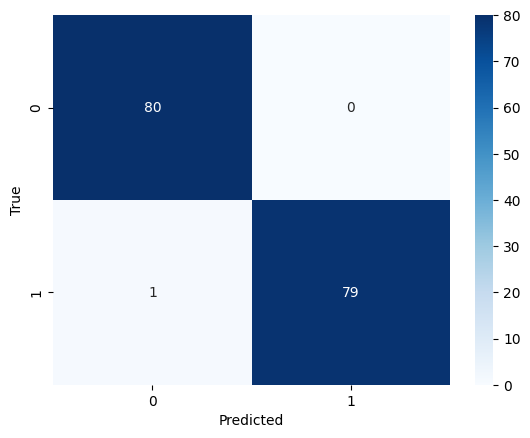

In [165]:
X, y, window_size, step_size, model, feature_names = grid_search_for_optimal_window_size(participant_id, window_sizes, step_sizes)

# 2. Feature selection via MDI

MDI (Mead Decrease in Impurity) scores for the features

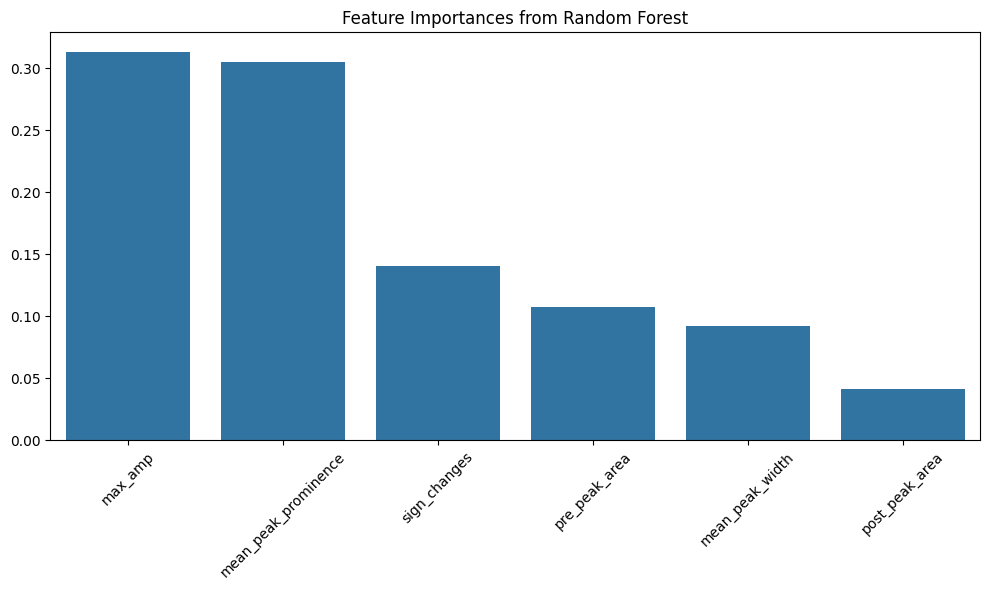

In [166]:
importances = model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=[feature_names[i] for i in sorted_idx], y=importances[sorted_idx])
plt.xticks(rotation=45)
plt.title("Feature Importances from Random Forest")
plt.tight_layout()
plt.show()

Select the top 3 features

In [167]:
selected_features = [feature_names[i] for i in sorted_idx][:3]
df = pd.DataFrame(X, columns=feature_names)
df = df[selected_features].round(2)
df["label"] = y

Optionally, save the features.

In [168]:
# df.to_csv("features_for_sirus.csv", index=False)

# 4. Rule-based classification using SIRUS

Now, we go to R to run the rule-extractor `SIRUS`, and get back the best fit rules.

In [169]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

# Push pandas DataFrame to R using context manager
with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv['features_for_sirus'] = ro.conversion.py2rpy(df)

# R code block
ro.r('''
require(sirus)
library(dplyr)

data <- features_for_sirus %>% select(1:3)  # First 3 columns as features
data <- as.data.frame(data)
y <- features_for_sirus$label

sirus.m <- sirus.fit(data, y)
rules <- capture.output(sirus.print(sirus.m))
y_pred <- ifelse(sirus.predict(sirus.m, data) < 0.5, 0, 1)
''')

# Pull back predictions and rules
with localconverter(ro.default_converter + pandas2ri.converter):
    y_pred = np.array(ro.r('y_pred'), dtype=int)
    rules = list(ro.r('rules'))


[1] "Number of trees:  1000  - Stability  92.82  %."
[1] "Number of trees:  2000  - Stability  95.22  %."


In [170]:
rules

[' [1] "Proportion of class 1 = 0.5 - Sample size n = 200"                                              ',
 ' [2] "if mean_peak_prominence < 53 then 0.97 (n=100) else 0.03 (n=100)"                               ',
 ' [3] "if max_amp < 71.9 then 0.98 (n=100) else 0.02 (n=100)"                                          ',
 ' [4] "if sign_changes < 11 then 0.145 (n=117) else 1 (n=83)"                                          ',
 ' [5] "if max_amp < 71.9 & sign_changes < 11 then 0.882 (n=17) else 0.464 (n=183)"                     ',
 ' [6] "if mean_peak_prominence >= 53 & sign_changes < 11 then 0.0102 (n=98) else 0.971 (n=102)"        ',
 ' [7] "if max_amp >= 71.9 & mean_peak_prominence >= 53 then 0 (n=95) else 0.952 (n=105)"               ',
 ' [8] "if mean_peak_prominence >= 53 & mean_peak_prominence < 69.2 then 0.15 (n=20) else 0.539 (n=180)"',
 ' [9] "if mean_peak_prominence < 26.5 then 1 (n=79) else 0.174 (n=121)"                                ',
 '[10] "if max_amp < 51.4 then 1 (n=8

In [171]:
df["rule_label"] = y_pred

In [172]:
df

,max_amp,mean_peak_prominence,sign_changes,label,rule_label
0,125.95,55.63,5.0,0.0,0
1,120.85,89.65,6.0,0.0,0
2,89.66,86.48,4.0,0.0,0
3,77.94,73.61,5.0,0.0,0
4,72.14,71.97,8.0,0.0,0
...,...,...,...,...,...
195,51.39,26.53,12.0,1.0,1
196,40.73,33.03,8.0,1.0,1
197,43.68,21.67,11.0,1.0,1
198,51.38,38.16,11.0,1.0,1


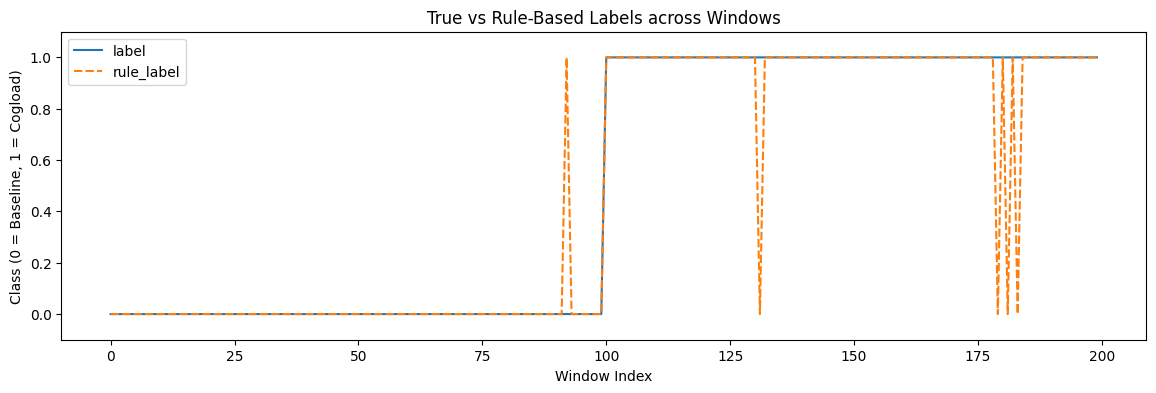

In [173]:
plt.figure(figsize=(14, 4))
sns.lineplot(data=df[['label', 'rule_label']])
plt.xlabel("Window Index")
plt.ylabel("Class (0 = Baseline, 1 = Cogload)")
plt.title("True vs Rule-Based Labels across Windows")
plt.legend()
plt.ylim(-0.1, 1.1)
plt.show()

In [174]:
accuracy = (df["label"] == df["rule_label"]).mean()
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.97
